In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("netflix_cleaned.csv")

In [9]:
df

,Show_ID,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,25-Sep-21,2020,PG-13,90 min,Documentaries
1,s2,Tv Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,Tv Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,Tv Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,s8804,Tv Show,Zombie Dumb,Not Specified,Not Specified,Not Specified,01-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,01-Nov-19,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies"


In [ ]:
df["Rating"].value_counts()

In [3]:
rating_counts = df["Rating"].value_counts()

rating_counts

Rating
TV-MA            3207
TV-14            2160
TV-PG             863
R                 799
PG-13             490
TV-Y7             334
TV-Y              307
PG                287
TV-G              220
NR                 80
G                  41
NOT SPECIFIED       7
TV-Y7-FV            6
NC-17               3
UR                  3
Name: count, dtype: int64

In [4]:
# Checking for missing ratings
df["Rating"].isnull().sum()

np.int64(0)

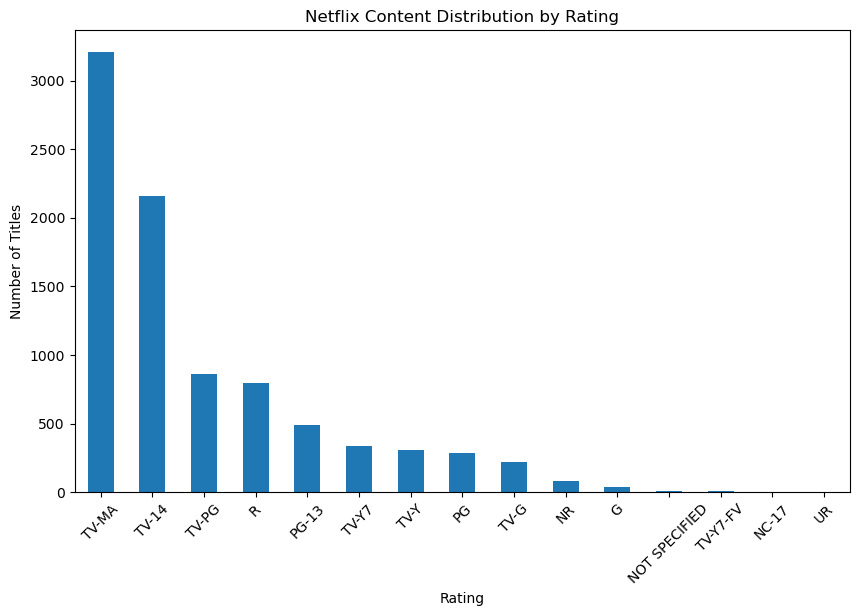

In [5]:
# Visualization 1: Netflix Content Distribution by Rating
plt.figure(figsize=(10, 6))

rating_counts.plot(kind="bar")

plt.title("Netflix Content Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [6]:
# Calculating the percentage of each rating
rating_percentage = df["Rating"].value_counts(normalize=True) * 100

rating_percentage.round(2)

Rating
TV-MA            36.41
TV-14            24.53
TV-PG             9.80
R                 9.07
PG-13             5.56
TV-Y7             3.79
TV-Y              3.49
PG                3.26
TV-G              2.50
NR                0.91
G                 0.47
NOT SPECIFIED     0.08
TV-Y7-FV          0.07
NC-17             0.03
UR                0.03
Name: proportion, dtype: float64

In [7]:
rating_by_type = pd.crosstab(df["Rating"], df["Type"])

rating_by_type

Type,Movie,Tv Show
Rating,,
G,41,0
NC-17,3,0
NOT SPECIFIED,5,2
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94


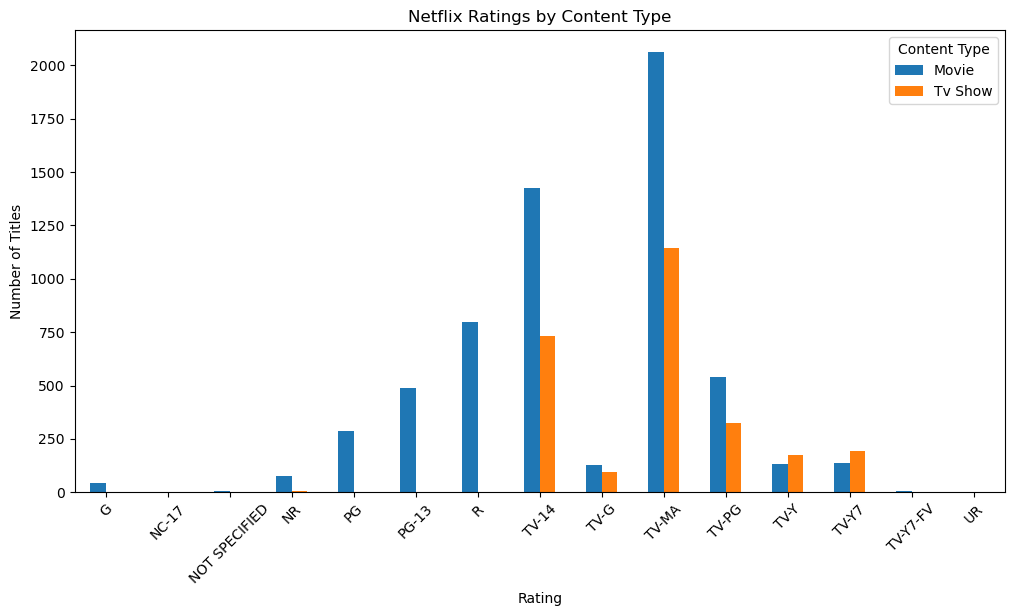

In [8]:
# Visualization 2: Netflix Ratings by Content Type
rating_by_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Content Type")

plt.show()

In [10]:
df["Genre"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: Genre, dtype: object

In [11]:
# Splitting genres into rows
genres = df["Genre"].dropna().str.split(", ")

In [12]:
genre_list = genres.explode()

In [13]:
genre_counts = genre_list.value_counts()

genre_counts.head(10)

Genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

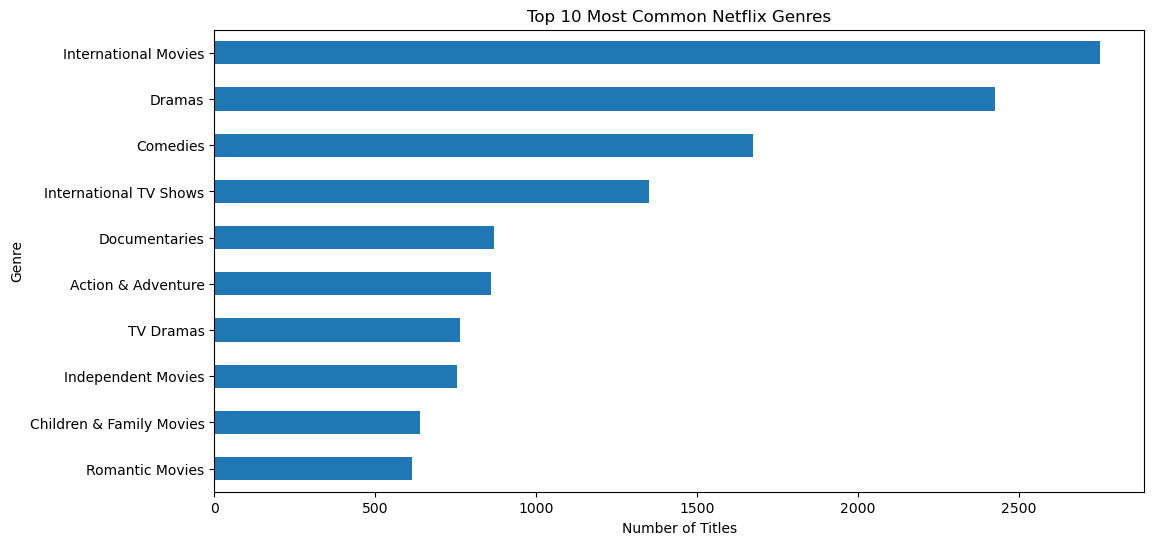

In [14]:
# Visualization 3: Top 10 Most Common Netflix Genres
top_genres = genre_counts.head(10)

plt.figure(figsize=(12, 6))

top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Most Common Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [15]:
# Calculating genre percentages
genre_percentage = (genre_counts / len(df)) * 100

genre_percentage.head(10).round(2)

Genre
International Movies        31.25
Dramas                      27.56
Comedies                    19.01
International TV Shows      15.34
Documentaries                9.87
Action & Adventure           9.75
TV Dramas                    8.66
Independent Movies           8.58
Children & Family Movies     7.28
Romantic Movies              6.99
Name: count, dtype: float64

In [16]:
rating_by_type

Type,Movie,Tv Show
Rating,,
G,41,0
NC-17,3,0
NOT SPECIFIED,5,2
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94


In [17]:
rating_percentage_by_type = pd.crosstab(
    df["Rating"],
    df["Type"],
    normalize="columns"
) * 100

In [18]:
rating_percentage_by_type.round(2)

Type,Movie,Tv Show
Rating,,
G,0.67,0.00
NC-17,0.05,0.00
NOT SPECIFIED,0.08,0.07
NR,1.22,0.19
PG,4.68,0.00
PG-13,7.99,0.00
R,13.00,0.07
TV-14,23.28,27.39
TV-G,2.06,3.51


In [19]:
rating_comparison = rating_percentage_by_type.reset_index()

rating_comparison

Type,Rating,Movie,Tv Show
0,G,0.668733,0.000000
1,NC-17,0.048932,0.000000
2,NOT SPECIFIED,0.081553,0.074738
3,NR,1.223291,0.186846
4,PG,4.681129,0.000000
5,PG-13,7.992171,0.000000
6,R,12.999511,0.074738
7,TV-14,23.275159,27.391629
8,TV-G,2.055130,3.512706
9,TV-MA,33.632360,42.787743


In [21]:
rating_df = rating_counts.reset_index()

rating_df.columns = ["Rating", "Count"]

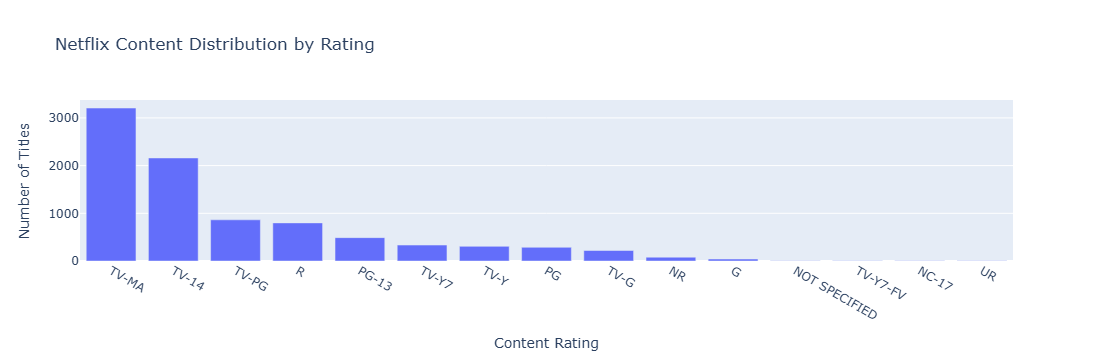

In [22]:
# Visualization 4: Netflix Content Distribution by Rating
fig = px.bar(
    rating_df,
    x="Rating",
    y="Count",
    title="Netflix Content Distribution by Rating",
    labels={
        "Rating": "Content Rating",
        "Count": "Number of Titles"
    },
    hover_data=["Count"]
)

fig.show()

In [23]:
audience_segments = pd.crosstab(
    df["Rating"],
    df["Type"]
)

audience_segments

Type,Movie,Tv Show
Rating,,
G,41,0
NC-17,3,0
NOT SPECIFIED,5,2
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94


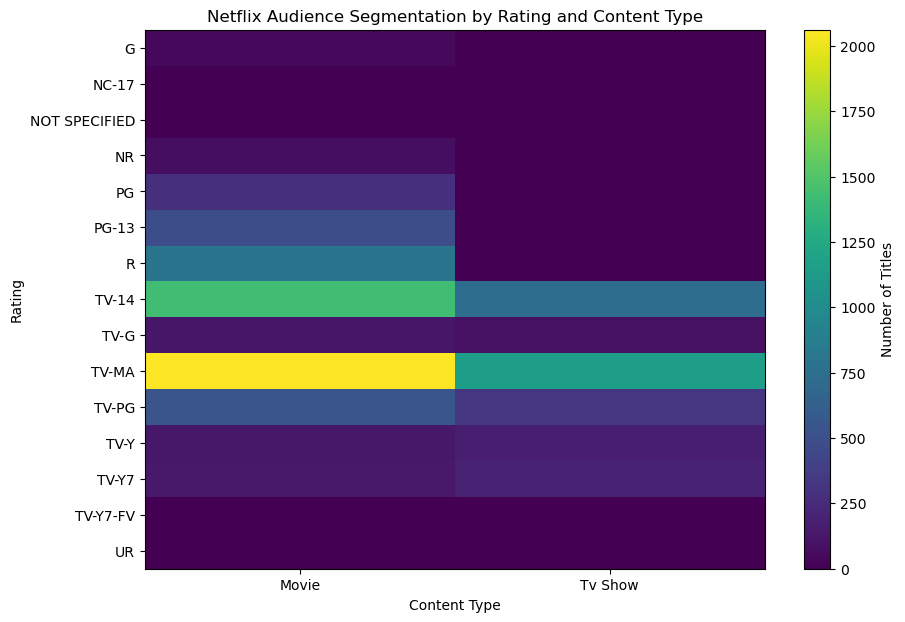

In [24]:
# Visualization 4: Netflix Audience Segmentation by Rating and Content Type
plt.figure(figsize=(10, 7))

plt.imshow(audience_segments, aspect="auto")

plt.title("Netflix Audience Segmentation by Rating and Content Type")
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.xticks(
    range(len(audience_segments.columns)),
    audience_segments.columns
)

plt.yticks(
    range(len(audience_segments.index)),
    audience_segments.index
)

plt.colorbar(label="Number of Titles")

plt.show()

## Insights

1. Mature audiences represent a significant portion of Netflix's content.
The high concentration of TV MA and TV 14 content indicates a strong focus on older teenagers and adult audiences.

2. Netflix has a broad genre portfolio.
Drama, International Movies, Comedies, and International TV Shows are among the most represented categories, showing that Netflix maintains a diverse content library.

3. Movies and TV Shows have different rating patterns.
The distribution of ratings varies between the two content types, suggesting that Netflix uses Movies and TV Shows to reach different audience segments.

4. Genre diversity supports audience segmentation.
The presence of multiple genres allows Netflix to appeal to viewers with different interests rather than relying on a single content category.

5. International content is an important part of Netflix's catalogue.
The strong presence of International Movies and International TV Shows demonstrates Netflix's focus on content that can appeal to audiences across different markets.

6. Content ratings can help Netflix target specific audience groups.
The concentration of content within particular rating categories provides an indication of the age groups and audience segments that Netflix prioritizes when developing and acquiring content.

7. Genre and rating analysis can support content strategy.
Combining genre preferences with rating patterns can help Netflix identify which types of content are most suitable for particular audience segments and markets.

## Conclusion

The analysis shows that Netflix maintains a diverse content library across different ratings, genres and content types. The distribution of ratings indicates a strong presence of content targeted toward mature audiences, while the wide range of genres demonstrates Netflix's strategy of serving different viewer preferences. Differences between Movies and TV Shows in both ratings and genres also highlight opportunities for audience segmentation.
Overall, rating and genre analysis provides useful insights into Netflix's content strategy and the different audience groups targeted by the platform.